In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [4]:
df = pd.read_csv("twitter_training.csv", header=None)

df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

print(df.head())

df.dropna(inplace=True)


     ID       Entity Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [5]:

X = df['Tweet']
y = df['Sentiment']



In [6]:

tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(X)



In [7]:

le = LabelEncoder()
y = le.fit_transform(y)



In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.8074324324324325
Confusion Matrix:
 [[1941  192  193  370]
 [ 128 3651  219  382]
 [ 125  217 2883  380]
 [ 146  271  227 3475]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77      2696
           1       0.84      0.83      0.84      4380
           2       0.82      0.80      0.81      3605
           3       0.75      0.84      0.80      4119

    accuracy                           0.81     14800
   macro avg       0.81      0.80      0.80     14800
weighted avg       0.81      0.81      0.81     14800



In [29]:
conf=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf)


Confusion Matrix:
 [[1941  192  193  370]
 [ 128 3651  219  382]
 [ 125  217 2883  380]
 [ 146  271  227 3475]]


In [28]:
class_rep=classification_report(y_test, y_pred)
print("Classification Report:\n", class_rep)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77      2696
           1       0.84      0.83      0.84      4380
           2       0.82      0.80      0.81      3605
           3       0.75      0.84      0.80      4119

    accuracy                           0.81     14800
   macro avg       0.81      0.80      0.80     14800
weighted avg       0.81      0.81      0.81     14800



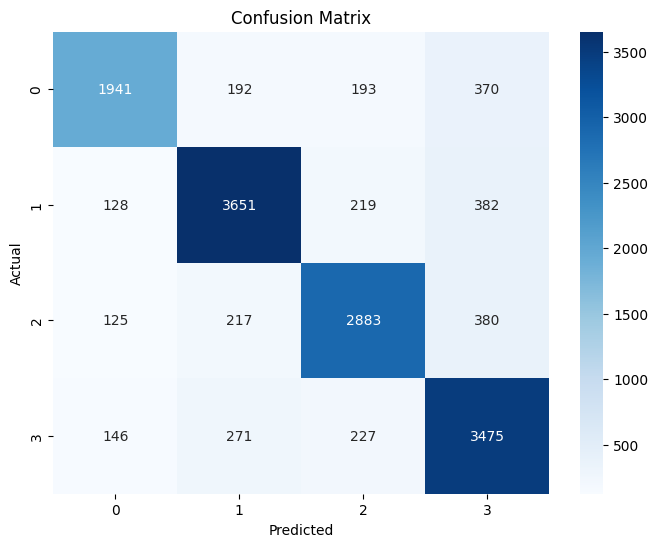

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()